# Speedup saturation model — Validation.

Reproduces Section 8 of the paper.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t as student_t
from saturation_model import CHIPS, calibrate, fit_knee

P = 10                    # n_features used in the benchmark
spec = CHIPS['M4']

raw = pd.read_csv('benchmark_data.csv')
raw = raw[raw.processor == 'M4'].copy()

def ci95(x):
    "Half-width of the 95% Student-t CI for the mean; 0 for a single trial."
    x = np.asarray(x, dtype=float)
    if x.size < 2:
        return 0.0
    return float(student_t.ppf(0.975, x.size - 1) * x.std(ddof=1) / np.sqrt(x.size))

# Collate the independent trials into the per-N mean curve + 95% CI the paper reports.
m4 = (raw.groupby(['split', 'N'])
         .agg(T_cpu_s=('T_cpu_s', 'mean'), T_cpu_ci=('T_cpu_s', ci95),
              T_gpu_s=('T_gpu_s', 'mean'), T_gpu_ci=('T_gpu_s', ci95),
              speedup=('speedup', 'mean'), speedup_ci=('speedup', ci95),
              n_trials=('speedup', 'size'))
         .reset_index()
         .sort_values('N'))

cheap     = m4[m4.split == 'train']
expensive = m4[m4.split == 'test']
print(f"{len(m4)} distinct N, up to {int(m4.n_trials.max())} trials each "
      f"({int(m4.n_trials.min())} at the largest N).")
m4

13 distinct N, up to 12 trials each (1 at the largest N).


,split,N,T_cpu_s,T_cpu_ci,T_gpu_s,T_gpu_ci,speedup,speedup_ci,n_trials
6,train,100,0.001052,0.000034,0.003775,0.000473,0.288533,0.036817,12
7,train,500,0.008673,0.000318,0.002990,0.000637,3.223176,0.714534,12
8,train,1000,0.030400,0.000560,0.003751,0.001087,9.439251,2.161895,12
9,train,2500,0.185322,0.003824,0.005877,0.000489,32.128207,3.205552,12
10,train,5000,0.673814,0.007633,0.011043,0.001443,63.465835,8.412226,12
11,train,7500,1.461194,0.011256,0.015010,0.002402,102.775051,15.093740,12
12,train,10000,2.553937,0.025589,0.022286,0.002636,118.166864,13.316010,12
0,test,20000,9.718877,0.061147,0.068284,0.001288,142.476899,3.434057,12
1,test,30000,21.491406,0.128213,0.149093,0.001454,144.180719,1.712508,12
2,test,40000,37.965625,0.085200,0.262164,0.001993,144.836326,1.205383,12


## The knee, from the GPU timing curve alone

$T_\mathrm{gpu}(N) = a_g N^2 P + b_g N + g_g$ is linear in its three coefficients,
so it is fitted directly by weighted least squares (Eq. `eq:knee_fit`) and the knee
read off as $N_\mathrm{sat} = b_g/(a_g P)$. 

The quadratic coefficient only becomes
visible once the $N^2$ term dominates; on `N ≤ 10k` alone the curve has barely begun
to bend. 

This stays inexpensive because it uses the **GPU pass only** ~1.6 s even
at `N = 100,000`, against ~234 s for the CPU pass at the same size. No CPU baseline
enters the knee at all.

In [2]:
knee = fit_knee(m4.N.values, m4.T_gpu_s.values, P, spec)

print("Table tab:fits — knee fit, full sweep (N <= 100k), GPU, weighted by 1/T_gpu")
print(f"  a_g^knee = {knee['a_g']:.4g} s/u     b_g^knee = {knee['b_g']:.4g} s"
      f"     g_g^knee = {knee['g_g']:.2g} s     R2 = {knee['r2']:.4f}")
print(f"\n  N_sat = b_g / (a_g P) = {knee['N_sat']:.0f}"
      f"      R = N_sat / C_gpu = {knee['R']:.0f} threads per core")

# The fitted launch overhead is independently checkable against the flat small-N tail.
flat = m4[m4.N <= 1000].T_gpu_s.mean()
print(f"  g_g^knee = {knee['g_g']*1e3:.2f} ms  vs  measured flat T_gpu(N<=1000) "
      f"= {flat*1e3:.2f} ms")

Table tab:fits — knee fit, full sweep (N <= 100k), GPU, weighted by 1/T_gpu
  a_g^knee = 1.47e-11 s/u     b_g^knee = 5.597e-07 s     g_g^knee = 0.0031 s     R2 = 0.9891

  N_sat = b_g / (a_g P) = 3806      R = N_sat / C_gpu = 381 threads per core
  g_g^knee = 3.14 ms  vs  measured flat T_gpu(N<=1000) = 3.51 ms


## $S_\infty$, calibrated on cheap data (N ≤ 10,000)

Both timing models are fitted on the cheap points only 
(`N ≤ 10,000`, where the most expensive CPU run is ~2.6 s), weighted by
$N^2$. 

In [3]:
cal = calibrate(cheap.N.values, cheap.T_cpu_s.values, cheap.T_gpu_s.values,
                P, spec, knee['N_sat'])

print("Table tab:fits — plateau calibration, cheap (N <= 10k), weighted by N^2")
print(f"  CPU   a_c = {cal.a_c:.3g} s/u     g_c = {cal.g_c:.2g} s     R2 = {cal.r2_cpu:.4f}")
print(f"  GPU   a_g = {cal.a_g:.3g} s/u     g_g = {cal.g_g:.2g} s     R2 = {cal.r2_gpu:.4f}")
print(f"\n  S_inf^pred = a_c / a_g = {cal.S_inf:.1f}x")
print(f"  measured max speedup over the whole sweep = {m4.speedup.max():.1f}x "
      f"(at N = {int(m4.loc[m4.speedup.idxmax(), 'N']):,})")

Table tab:fits — plateau calibration, cheap (N <= 10k), weighted by N^2
  CPU   a_c = 2.51e-09 s/u     g_c = 0.044 s     R2 = 1.0000
  GPU   a_g = 1.61e-11 s/u     g_g = 0.0062 s     R2 = 0.9914

  S_inf^pred = a_c / a_g = 155.9x
  measured max speedup over the whole sweep = 148.4x (at N = 100,000)


### Table `tab:timings` 

At small `N` the GPU offers little or no advantage

At `N = 100` it is in fact slower, because the ~3 ms launch overhead dominates. 

As `N` grows the speedup climbs steeply.

In [4]:
def pm(v, ci, fmt):
    return f"{v:{fmt}} +- {ci:{fmt}}" if ci > 0 else f"{v:{fmt}}"

print(f"{'N':>7}  {'T_cpu (s)':>22}  {'T_gpu (s)':>22}  {'S_N':>18}")
for r in cheap.itertuples():
    print(f"{r.N:>7,}  {pm(r.T_cpu_s, r.T_cpu_ci, '.5f'):>22}  "
          f"{pm(r.T_gpu_s, r.T_gpu_ci, '.5f'):>22}  "
          f"{pm(r.speedup, r.speedup_ci, '.2f'):>18}")

      N               T_cpu (s)               T_gpu (s)                 S_N
    100      0.00105 +- 0.00003      0.00378 +- 0.00047        0.29 +- 0.04
    500      0.00867 +- 0.00032      0.00299 +- 0.00064        3.22 +- 0.71
  1,000      0.03040 +- 0.00056      0.00375 +- 0.00109        9.44 +- 2.16
  2,500      0.18532 +- 0.00382      0.00588 +- 0.00049       32.13 +- 3.21
  5,000      0.67381 +- 0.00763      0.01104 +- 0.00144       63.47 +- 8.41
  7,500      1.46119 +- 0.01126      0.01501 +- 0.00240     102.78 +- 15.09
 10,000      2.55394 +- 0.02559      0.02229 +- 0.00264     118.17 +- 13.32


### Table `tab:err` Held-out predictions

$S_\infty^{\mathrm{pred}}$, together with the knee measured from the GPU curve,
predicts every held-out point via $S_N = S_\infty N/(N+N_\mathrm{sat})$

In [5]:
S_meas = expensive.speedup.values
S_pred = cal.predict_speedup(expensive.N.values)
E_rel  = np.abs(S_pred - S_meas) / S_meas * 100

print(f"{'N':>7}  {'T_cpu (s)':>18}  {'T_gpu (s)':>18}  {'S_meas':>14}  "
      f"{'S_pred':>8}  {'E_rel':>6}")
for r, sm, sp, e in zip(expensive.itertuples(), S_meas, S_pred, E_rel):
    print(f"{r.N:>7,}  {pm(r.T_cpu_s, r.T_cpu_ci, '.3f'):>18}  "
          f"{pm(r.T_gpu_s, r.T_gpu_ci, '.4f'):>18}  "
          f"{pm(sm, r.speedup_ci, '.1f'):>14}  {sp:>7.1f}x  {e:>5.1f}%")
print(f"\n{'mean / max':>67}  {E_rel.mean():.1f}% / {E_rel.max():.1f}%")
print(f"\nS_inf^pred = {cal.S_inf:.1f}x is within "
      f"{abs(cal.S_inf - S_meas[-1]) / S_meas[-1] * 100:.1f}% of the measured "
      f"S_100k = {S_meas[-1]:.1f}x.")

      N           T_cpu (s)           T_gpu (s)          S_meas    S_pred   E_rel
 20,000      9.719 +- 0.061    0.0683 +- 0.0013    142.5 +- 3.4    131.0x    8.1%
 30,000     21.491 +- 0.128    0.1491 +- 0.0015    144.2 +- 1.7    138.3x    4.1%
 40,000     37.966 +- 0.085    0.2622 +- 0.0020    144.8 +- 1.2    142.3x    1.7%
 60,000     84.812 +- 0.056    0.5780 +- 0.0030    146.7 +- 0.7    146.6x    0.1%
 80,000             149.745              1.0244           146.2    148.8x    1.8%
100,000             234.401              1.5796           148.4    150.2x    1.2%

                                                         mean / max  2.8% / 8.1%

S_inf^pred = 155.9x is within 5.0% of the measured S_100k = 148.4x.


### Figure `fig:speedup` — speedup versus dataset size

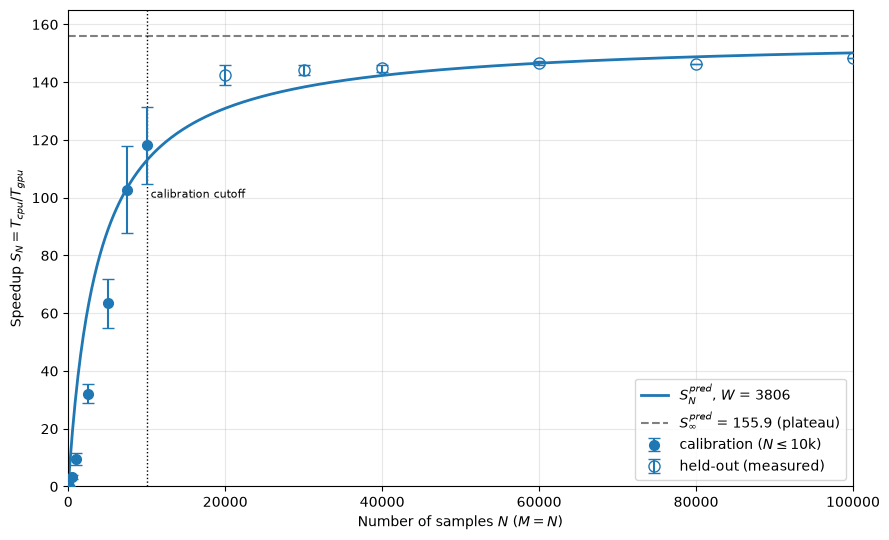

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5))
Nx = np.linspace(0, 105000, 600)

ax.plot(Nx, cal.predict_speedup(Nx), '-', c='tab:blue', lw=2,
        label=f"$S_N^{{pred}}$, $W$ = {knee['N_sat']:.0f}")
ax.axhline(cal.S_inf, ls='--', c='gray',
           label=f'$S_\\infty^{{pred}}$ = {cal.S_inf:.1f} (plateau)')
ax.errorbar(cheap.N, cheap.speedup, yerr=cheap.speedup_ci, fmt='o', c='tab:blue',
            ms=7, capsize=4, zorder=5, label='calibration ($N\\leq$10k)')
ax.errorbar(expensive.N, expensive.speedup, yerr=expensive.speedup_ci, fmt='o',
            mfc='none', c='tab:blue', ms=8, capsize=4, zorder=5,
            label='held-out (measured)')
ax.axvline(10000, ls=':', c='k', lw=1)
ax.annotate('calibration cutoff', xy=(10500, 100), fontsize=8)

ax.set_xlabel('Number of samples $N$ ($M = N$)')
ax.set_ylabel('Speedup $S_N = T_{cpu}/T_{gpu}$')
ax.set_xlim(0, 100000); ax.set_ylim(0, 165)
ax.grid(alpha=.3); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()